[[81.96548045 82.1404535  79.27005083 71.05005445 74.046626  ]
 [60.59726667 62.44406876 52.67940526 85.21524689 83.86965752]
 [48.75796683 63.56430474 67.80668736 62.53793717 67.30195389]
 [48.92385825 54.35380796 61.26447808 58.15934313 61.80097254]
 [74.34712752 68.60796081 70.17485127 75.63800026 65.53747106]
 [59.04506737 72.58002114 68.93290233 72.98027846 70.31508069]
 [79.14249856 67.18005643 77.30701486 72.07479449 65.45729724]
 [84.7682704  76.22252939 76.77416047 65.61431457 74.8697678 ]
 [51.37388891 59.85783707 51.88077093 56.21286045 52.71918494]
 [77.78033877 81.69677625 81.47416142 71.65422722 68.03572543]
 [69.06522004 62.4236184  68.16924076 61.22077789 62.54516938]
 [51.55853386 67.54409441 59.47451029 64.02780178 64.49791458]
 [65.21668533 61.48624923 68.98655844 56.03042962 59.15702027]
 [85.3268166  84.16243266 77.27001366 83.60977802 75.68739287]
 [65.79151118 65.6195584  69.76976761 63.27783924 66.49196368]
 [72.3366973  64.70214069 75.49727178 55.21829488 60.20

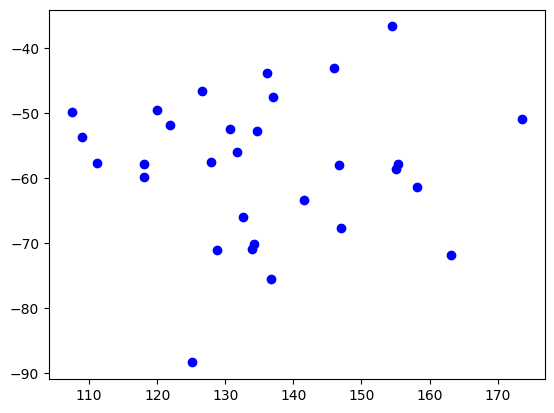

In [28]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt 

n = 30

tec = np.random.normal(70, 10,n)                   # np.random.normal(media,desviacion,n)
crea = np.random.normal(65,10,n)

x1 = tec + np.random.normal(0,5,n)
x2 = tec + np.random.normal(0,5,n)
x3 = tec + np.random.normal(0,5,n)

x4 = crea  + np.random.normal(0,5,n)
x5 = crea + np.random.normal(0,5,n)

X = np.vstack([x1,x2,x3,x4,x5]).T      # vertical stack apilando arreglos
print(X)
u = np.mean(X,axis=0)
X_ = X - u                               # X- u   centrado de datos
cov = X_.T @ X_/n                        # COVARIANZA
print(cov)
val , vec = np.linalg.eig(cov)          # valores y vectores propios
arr = [1,4,2]
def ordenar_indices(arr):              # ordena y obtiene los indices 
    n = len(arr)
    ind = list(range(n))
    arr_ = arr.copy()
    for i in range(n-2,-1,-1):
        a = arr_[i]
        id_ = ind[i]
        j = i + 1
        while j<=n-1 and arr_[j]>a:
            arr_[j - 1] = arr_[j]
            ind[j - 1] = ind[j]
            j = j + 1
        arr_[j - 1] = a
        ind[j - 1] = id_
    return ind 
inds  = ordenar_indices(val) 
val_ =val[inds]                # lmayor, ...
vec_ = vec[:,inds]             # vmayor, v,,
#Col 1    Col 2    Col 3
#    ┌                          ┐
#    │  2.5      2.0     -3.0    │  <- Fila 1
#    │  3.5      3.0     -2.0   │  <- Fila 2
#Xc =│ -3.5     -2.0      3.0   │  <- Fila 3
#    │ -2.5     -3.0      2.0   │  <- Fila 4
#    └                          ┘ 
#   v1≈(0.63,0.52,−0.58)
#  PC1=0.63(Mate)+0.52(Fıˊsica)−0.58(Comunicacioˊn)

# proyeccion 
#  X v1  =   DATOS CENTRADOS (Xc)               PROYECCIÓN PCA (Z)
#    Col 1    Col 2    Col 3               PC1 (Varianza Máx)
#  ┌                          ┐                ┌        ┐
#  │  2.5      2.0     -3.0   │       ─────▶   │  4.36  │  Persona A
#  │  3.5      3.0     -2.0   │0.63    ─────▶  │  4.92  │  Persona B
#  │ -3.5     -2.0      3.0   │0.52    ─────▶  │ -4.98  │  Persona C
#  │ -2.5     -3.0      2.0   │-0.58   ─────▶  │ -4.29  │  Persona D
#  └                          ┘                └        ┘
#    (3D: Espacio original)             (1D: Resumen)
print(vec_[0])
por = [ v/sum(val_) for v in val_] 
print(por)
z1 = X@vec_[:,0]
z2 = X@vec_[:,1]
plt.scatter(z1,z2,color='blue')
plt.show() 

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

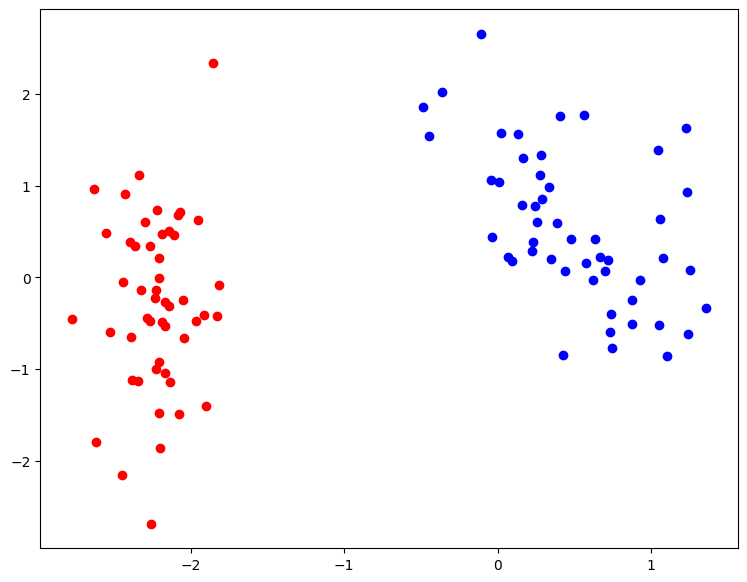

[np.float64(72.96244541329993), np.float64(22.85076178670174), np.float64(3.6689218892828674), np.float64(0.5178709107154726)]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_iris

class PCA:
    #----------------------------------
    def __init__(self):
        self.k = 2
        self.val = None
    #----------------------------------
    def ordenar_indices(self,v):
        n = len(v)
        inds = list(range(n))
        v_ = v.copy()
        for i in range(n-2,-1,-1):
            dat = v_[i]
            id_ = inds[i]
            j = i + 1
            while j<=n-1 and v_[j]>dat:
                v_[j - 1 ] = v_[j]
                inds[j - 1] = inds[j]
                j = j + 1
            v_[j - 1] = dat
            inds[j - 1 ]  =id_
        return inds
    #-----------------------------------
    def transformar_entrenar(self,X):
        n,_ = X.shape
        u = X.mean(axis=0)
        sigma = X.std(axis=0)
        X_ = X.copy()
        X_ = (X - u )/sigma
        cov = X_.T @ X_ / n
        val , vec = np.linalg.eig(cov)
        print(f"val  {val}")
        inds = self.ordenar_indices(val)
        val_ = val[inds]
        self.val = val_
        vec_  = vec[:,inds]              # v1 ,v2
        z = X_ @ vec_[:,:self.k]    # proyeccion
        return z                  #pc1,pc2  
    #--------------------------------------
    def porcentaje_explicado(self):
        val = self.val
        porcentajes = [(v/val.sum())*100 for v in val]
        return porcentajes
    #------------------------------------------
    def graficar(self,z,y):
        plt.figure(figsize=(9,7))
        mascara = y == 0             # filas con etiqueta 0
        z1 = z[mascara,0]         # filas que cumplen , columa 0
        z2 = z[mascara,1]
        plt.scatter(z1,z2,color='red')
        mascara = y ==1
        z1_ = z[mascara,0]
        z2_ = z[mascara,1]
        plt.scatter(z1_,z2_,color='blue')
        plt.show()
    #-----------------------------------------
    
#=================================================
if __name__=='__main__':
    pca = PCA()
    #data = load_breast_cancer()
    data = load_iris()
    X = data.data
    y = data.target
    print(X)
    print(y)
    z = pca.transformar_entrenar(X)
    pca.graficar(z,y)
    porcentajes = pca.porcentaje_explicado()
    print(porcentajes)


 {'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 

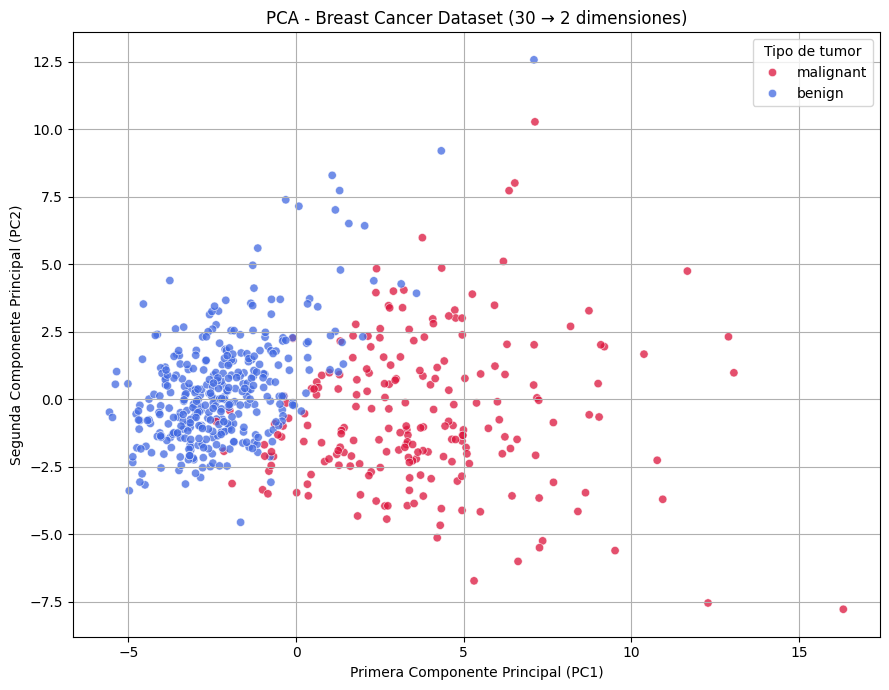

In [4]:
#SKLEARN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
# Cargar dataset
data = load_breast_cancer()
print("\n",data)                                                                                                                          
X = data.data          # (569, 30)
y = data.target        # 0 = maligno, 1 = benigno
target_names = data.target_names
print("\n\n",target_names)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)) 
])
X_pca = pipeline.fit_transform(X)
pca = pipeline.named_steps["pca"]

print("Varianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

print(f"\nVarianza total explicada: {pca.explained_variance_ratio_.sum():.4f}")
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=[target_names[i] for i in y],
    palette=["crimson", "royalblue"],
    alpha=0.75
)

plt.title("PCA - Breast Cancer Dataset (30 → 2 dimensiones)")
plt.xlabel("Primera Componente Principal (PC1)")
plt.ylabel("Segunda Componente Principal (PC2)")
plt.legend(title="Tipo de tumor")
plt.grid(True)
plt.tight_layout()
plt.show()



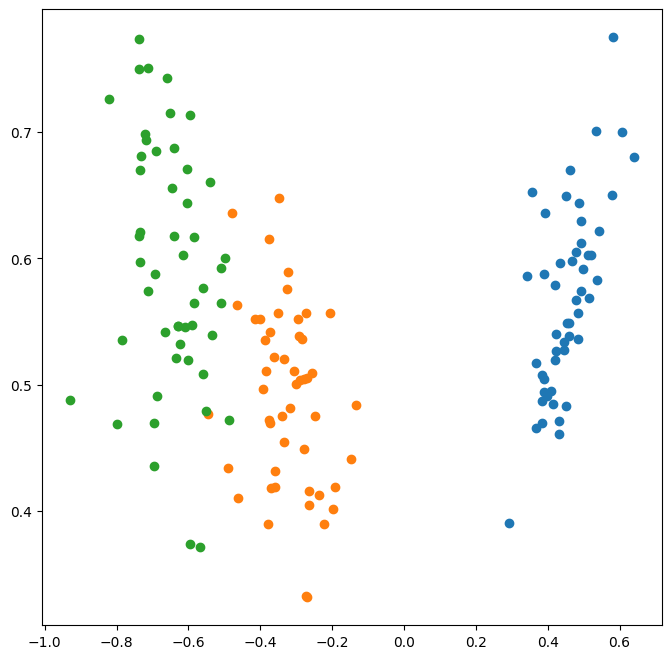

In [2]:
# LDA
import numpy as np
from sklearn.datasets import load_iris
from scipy.linalg import eigh
#============================================================
class LDA:
    #-------------------------------------------------------
    def __init__(self,k):
        self.k = k
        self.X = None
        self.y = None
        self.val = None
        self.z = None
        self.clases = None
    #------------------------------------------------------
    def determinar_clases(self,Y):
        clases = []
        for y in Y:
            if y not in clases:
                clases.append(y)
        self.clases = clases
        self. k = len(clases)
        return clases                   # 0,1...
# id X1  X2  Clase
# 0  2   3    0
# 1  3   3    0
# 2  2   4    0
# 3  5   2    1
# 4  6   2    1   mascara = [0,1,2] clase 0
# 5  6   3    1
    #-------------------------------------------------------
    def medias_k(self,clases,X,y):
        #clases = self.clases(y)
        medias_k = [0]*len(clases)
        for i,c in enumerate(clases):
            mascara = y == c
            medias_k[i] = X[mascara].mean(axis = 0)
        return medias_k
    #------------------------------------------------------
    def dispersion_intra_clases(self,X,y,medias_k):
        m, n = X.shape
        clases = self.determinar_clases(y)
        #medias_k = medias_k(clases,X,y)
        SW = np.zeros((n,n))
        for i,c in enumerate(clases):
            xc_uc = X[y==c] - medias_k[i]
            SWc = xc_uc.T @ xc_uc
            SW +=SWc
        return SW
#
# SW = SW0 + SW1 = |1.34  -0.66|
#                  |-0.66 1.34|
    #------------------------------------------------------
    def n_s(self,clases,X,y):
        n_s = [0]*len(clases)
        for i,c in enumerate(clases):
            mascara = y ==c
            n_s[i] = len(X[mascara])
        return n_s
    #-------------------------------------------------------
    def dispersion_inter_clases(self,X,y,medias_k):
        u = X.mean(axis = 0)
        m ,n = X.shape
        SB = np.zeros((n,n))
        clases = self.determinar_clases(y)
        n_s = self.n_s(clases,X,y)
        for i,c in enumerate(clases): 
            uk_u = (medias_k[i] - u).reshape(n,1)
            SB_c = n_s[i] * uk_u @ uk_u.T
            SB +=SB_c
        return SB
# SB = SB0 + SB1 = |16.74 -5.01|
#                  |-5.01 1.5 |
    #--------------------------------------------------------
    def ordenar_indices(self,arr):
        n = len(arr)
        arr_ = arr.copy()
        inds = list(range(n))
        for i in range(n-2,-1,-1):
            e = arr_[i]
            ids = inds[i]
            j = i + 1
            while j<=n-1 and arr_[j]>e:     # [4, 2, 7, 1] ,  7 [1]
                arr_[j - 1] = arr_[j]
                inds[j - 1] = inds[j]
                j = j + 1
            arr_[j - 1] = e
            inds[j - 1] = ids
        return inds
    #--------------------------------------------------------
    def transformar_entrenar(self,X,y,normalizar='estandarizar'):
        self.X = X
        self.y = y
        clases = self.determinar_clases(y)
        medias_k = self.medias_k(clases,X,y)
        SW = self.dispersion_intra_clases(X,y,medias_k)
        SB = self.dispersion_inter_clases(X,y,medias_k)
        #val, vec = np.linalg.eig(np.linalg.inv(SW)@SB)
        val , vec = eigh(SB,SW)
        ids = self.ordenar_indices(val)
        z = X@vec[:,ids]  
        return z
    #-----------------------------------------------------
    def graficar(self,z):
        plt.figure(figsize=(8,8))
        for i,c in enumerate(self.clases):
            mascara = self.y == c
            z1 = z[mascara,0]
            z2 = z[mascara,1]
            plt.scatter(z1,z2)
        plt.show()
    #------------------------------------------------------
#=============================================================
if __name__=='__main__':
    data = load_iris()
    X, y = data.data, data.target 
    lda = LDA(k=2)
    z = lda.transformar_entrenar(X,y)
    lda.graficar(z)

In [5]:
# SKLEARN 

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
data = load_iris()
X, y = data.data, data.target
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)
print(f"Varianza explicada por componentes: {lda.explained_variance_ratio_}")


Varianza explicada por componentes: [0.9912126 0.0087874]


shape (150, 4)


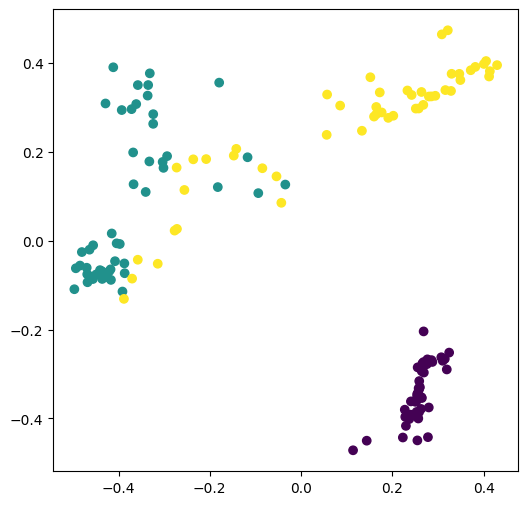

In [7]:
# corteria de gpt  , customizado a mi estilo

import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

#=======================================================
class T_SNE:
    #-----------------------------------------------------------
    def __init__(self):
        return
    #-----------------------------------------------------------
    def distancias_(self,X):
        m,n = X.shape
        D = np.zeros((m,m))
        for i in range(m):
            for j in range(m):
                D[i,j] = np.sum((X[i]-X[j])**2)
        return D
    #-----------------------------------------------------------
    def distancias(self,X):  #||x||² + ||x||² − 2x·x
        m , n = X.shape
        sum_X = np.sum(X**2,axis=1)
        A = sum_X.reshape(m,1) 
        B = sum_X.reshape(1,m)
        D = A + B -2 *X@X.T
        return D
     #-------------------------------------------------------------
    def similitudes_espacio_original(self,D, sigma=1.0):
        m = D.shape[0]
        P = np.zeros((m,m))
        for i in range(m):
            z = 0
            for j in range(m):
                if i != j:
                    P[i,j] = np.exp(-D[i,j]/(2*sigma**2))
                    z += P[i,j]
            for j in range(m):
                if i!=j:
                    P[i,j]/=z
        P = (P + P.T) / (2*m)                                   # simetrizando (p(j|i) + p(i|j)) / 2N
        return P
    #-----------------------------------------------------------
    def similitudes_con_perplejidad(self,D,per=30,tol=1e-5,max_iter=50): 
        m = D.shape[0]
        P = np.zeros((m,m))
        logU = np.log(per)                   #Perplexity(Pi)=2^H(Pi),   H(Pi)=−j∑Pj∣i log2Pj∣i
        for i in range(m):
            beta = 1.0                               # beta = 1/(2*sigma^2)
            betamin = -np.inf
            betamax = np.inf
            Di = np.delete(D[i], i)  
            for _ in range(max_iter):
                # Numerador
                Pi = np.exp(-Di * beta)
                Z = Pi.sum()
                Pi /= Z
                # Entropía
                H = -np.sum(Pi*np.log(Pi))
                Hdiff = H - logU
                if abs(Hdiff) < tol:
                    break
                if Hdiff > 0:
                    betamin = beta
                    beta = beta*2 if betamax==np.inf else (beta+betamax)/2
                else:
                    betamax = beta
                    beta = beta/2 if betamin==-np.inf else (beta+betamax)/2
            # Poner en la matriz final
            idx = [j for j in range(m) if j != i]
            P[i, idx] = Pi
        return (P + P.T)/(2*m)
    #------------------------------------------------------------
    def probabilidades_espacio_reducido(self,Y):
        m = Y.shape[0]
        Q = np.zeros((m,m))
        for i in range(m):
            for j in range(m):
                if i != j:
                    Q[i,j] = 1 / (1 + np.sum((Y[i]-Y[j])**2))
        Q /= np.sum(Q)
        return Q
    #----------------------------------------------------------------
    def probabilidades_espacio_reducido_(self,Y):
        m,n = Y.shape
        sum_Y = np.sum(Y**2,axis=1)
        A = sum_Y.reshape(m,1)
        B = sum_Y.reshape(1,m)
        D = A + B - 2 * Y @ Y.T
        Q = 1 /(1 + D)
        np.fill_diagonal(Q,0)                # diagonal 0's
        Q /=np.sum(Q)
        return Q
    #------------------------------------------------------------
    def gradiente(self,P,Q,Y):
        m = Y.shape[0]
        dY = np.zeros_like(Y)
        for i in range(m):
            for j in range(m):
                if i != j:
                    dY[i] += 4*(P[i,j]-Q[i,j]) * (Y[i]-Y[j]) / (1 + np.sum((Y[i]-Y[j])**2))
        return dY
    #-----------------------------------------------------------------------------------
    def gradiente_(self,P,Q,Y):                   # optimizado, entender luego
        sum_Y = np.sum(Y**2, axis=1)
        D = sum_Y[:,None] + sum_Y[None,:] - 2 * Y @ Y.T
        inv = 1 / (1 + D)
        np.fill_diagonal(inv, 0)
        PQ = (P - Q) * inv
        dY = 4 * (np.diag(np.sum(PQ, axis=1)) - PQ) @ Y
        return dY
    #--------------------------------------------------------------------------------
    def transformar_entrenar(self,X,N=500,lr =0.1,momentum=0.8):
        D = self.distancias(X)
        P = self.similitudes_con_perplejidad(D)
        m,n = X.shape
        Y = np.random.randn(m,2)*0.01
        Y_previo = Y.copy()
        for _ in range(N):
            Q = self.probabilidades_espacio_reducido_(Y)
            dy = self.gradiente_(P,Q,Y)                              # en lugar de movernos en direccion de gradiente,agregamos un empuje en la iteracion anterior
            Y_nuevo = Y - lr * dy + momentum*(Y - Y_previo )        #(t+1)=Y(t)−lr⋅∇C+momentum⋅(Y(t)−Y(t−1))
            Y_previo , Y = Y, Y_nuevo
        return Y
    #----------------------------------------------------------------------------------
    def graficar(self,Y,y):
        plt.figure(figsize=(6,6)) 
        plt.scatter(Y[:,0],Y[:,1],c = y)
        plt.show()
    #-----------------------------------------------------------------------
#==============================================================================================
if __name__=='__main__':
    #data = load_digits()
    data = load_iris()
    X, y = data.data, data.target
    print(f"shape {X.shape}")
    t_sne = T_SNE()
    Y = t_sne.transformar_entrenar(X)
    t_sne.graficar(Y,y)
    

C:\Users\USUARIO\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


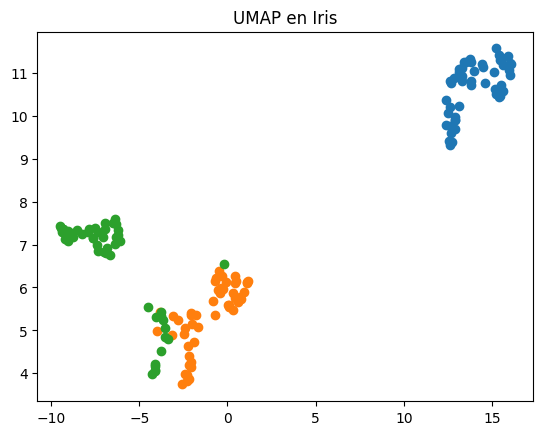

In [3]:
# UMAP 
# segun gpt es un algoritmo mas complejo 

import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X, y = data.data, data.target

modelo = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = modelo.fit_transform(X)

for clase in np.unique(y):
    plt.scatter(X_umap[y==clase,0],
                X_umap[y==clase,1])

plt.title("UMAP en Iris")
plt.show()

Dimensiones X: (569, 30)
Target names: ['malignant' 'benign']
Varianza explicada por componente:
PC1: 0.4427
PC2: 0.1897
Varianza total explicada (2 PCs): 0.6324

Loadings (influencia de cada variable en PC1 y PC2):
                           PC1    PC2
mean radius              0.798 -0.558
mean texture             0.378 -0.143
mean perimeter           0.830 -0.514
mean area                0.806 -0.552
mean smoothness          0.520  0.444
mean compactness         0.873  0.363
mean concavity           0.943  0.144
mean concave points      0.951 -0.083
mean symmetry            0.504  0.455
mean fractal dimension   0.235  0.875
radius error             0.751 -0.252
texture error            0.064  0.215
perimeter error          0.771 -0.214
area error               0.740 -0.364
smoothness error         0.053  0.488
compactness error        0.622  0.556
concavity error          0.560  0.471
concave points error     0.669  0.311
symmetry error           0.155  0.439
fractal dimension error 

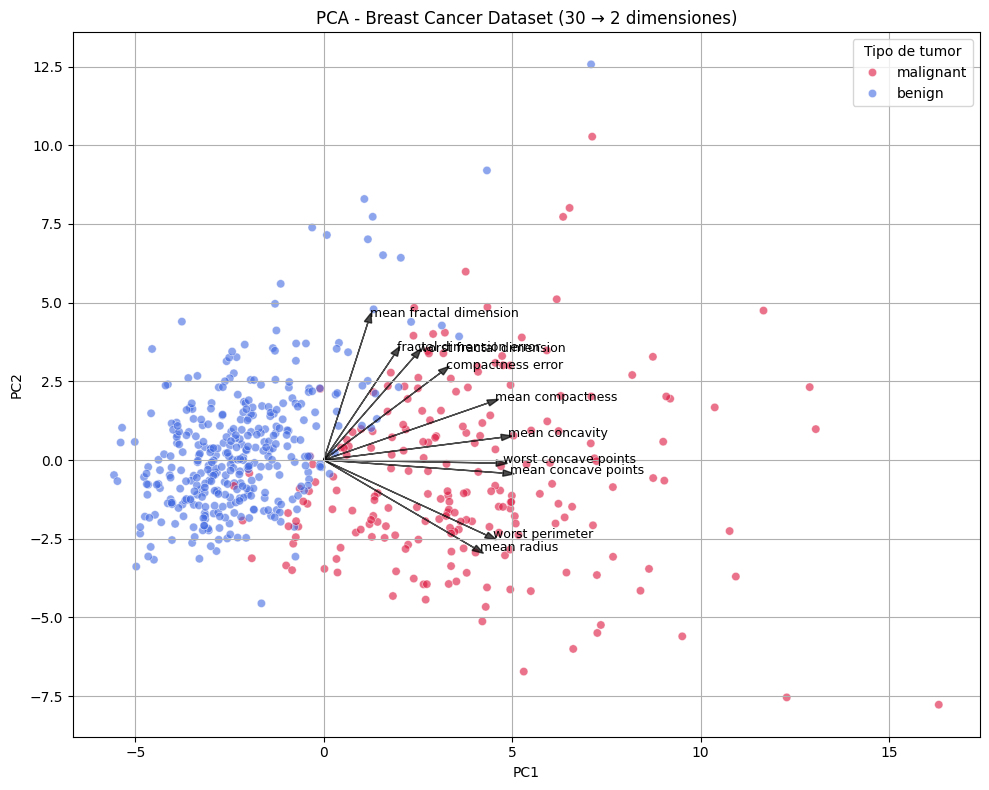

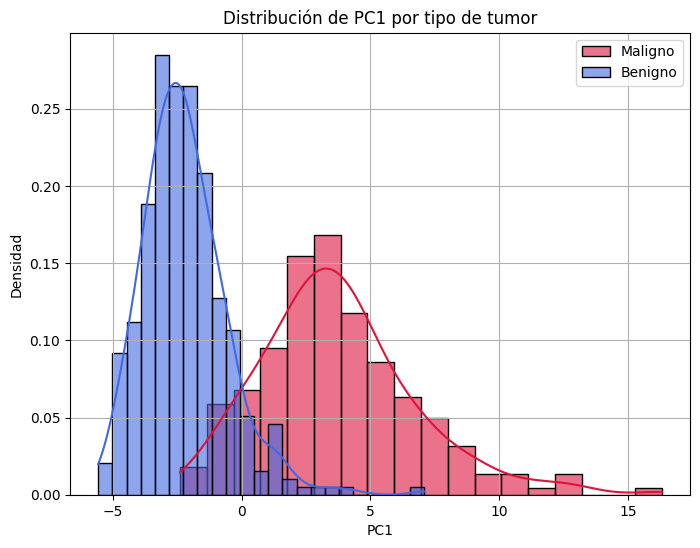

In [8]:
# pca g  p   t
# ==============================
# PCA completo Breast Cancer Dataset
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ------------------------------
# 1️ Cargar datos
# ------------------------------
data = load_breast_cancer()
X = data.data           # 569 filas x 30 características
y = data.target         # 0=maligno, 1=benigno
feature_names = data.feature_names
target_names = data.target_names

print("Dimensiones X:", X.shape)
print("Target names:", target_names)
# Output esperado:
# Dimensiones X: (569, 30)
# Target names: ['malignant' 'benign']

# ------------------------------
# 2️ Pipeline PCA con normalización
# ------------------------------
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42))
])

X_pca = pipeline.fit_transform(X)
pca = pipeline.named_steps["pca"]

# Varianza explicada
print("Varianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")
print(f"Varianza total explicada (2 PCs): {pca.explained_variance_ratio_.sum():.4f}")
# Ejemplo de salida:
# PC1: 0.4427
# PC2: 0.1893
# Varianza total explicada (2 PCs): 0.6320

# ------------------------------
# 3️ Matriz de correlación y loadings
# ------------------------------
scaler = pipeline.named_steps["scaler"]
X_scaled = scaler.transform(X)

# Loadings: influencia de cada variable original en PCs
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, index=feature_names, columns=["PC1","PC2"])
print("\nLoadings (influencia de cada variable en PC1 y PC2):")
print(loading_df.round(3))
# Ejemplo de salida:
# pc1      pc2
# mean radius        0.97   0.12
# mean texture       0.13  -0.45
# ...
# worst fractal dimension 0.02 0.11

# Matriz de correlación variables originales ↔ PCs
corr_matrix = np.corrcoef(X_scaled.T, X_pca.T)[:X_scaled.shape[1], X_scaled.shape[1]:]
corr_df = pd.DataFrame(corr_matrix, index=feature_names, columns=["PC1","PC2"])
print("\nCorrelación variables originales con PCs:")
print(corr_df.round(3))
# Ejemplo de salida:
#                        PC1    PC2
# mean radius          0.97   0.12
# mean texture         0.13  -0.45
# ...

# ------------------------------
# 4️ Scatter plot con flechas de variables más influyentes
# ------------------------------
top5_PC1 = loading_df["PC1"].abs().sort_values(ascending=False).head(5).index
top5_PC2 = loading_df["PC2"].abs().sort_values(ascending=False).head(5).index

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1],
    hue=[target_names[i] for i in y],
    palette=["crimson","royalblue"],
    alpha=0.6
)
plt.title("PCA - Breast Cancer Dataset (30 → 2 dimensiones)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Añadir flechas de las 5 variables más influyentes
for feature in top5_PC1.union(top5_PC2):
    plt.arrow(0, 0, 
              loading_df.loc[feature, "PC1"]*5,
              loading_df.loc[feature, "PC2"]*5, 
              color='black', alpha=0.7, head_width=0.2)
    plt.text(loading_df.loc[feature, "PC1"]*5.2,
             loading_df.loc[feature, "PC2"]*5.2,
             feature, color='black', fontsize=9)
plt.grid(True)
plt.legend(title="Tipo de tumor")
plt.tight_layout()
plt.show()
# Output esperado: scatter donde se ven los clusters benigno/maligno
# y flechas de las variables más influyentes apuntando en la dirección de mayor contribución.

# ------------------------------
# 5️ Histograma PC1 para clasificación (bonus)
# ------------------------------
plt.figure(figsize=(8,6))
sns.histplot(X_pca[y==0,0], color="crimson", label="Maligno", kde=True, stat="density", alpha=0.6)
sns.histplot(X_pca[y==1,0], color="royalblue", label="Benigno", kde=True, stat="density", alpha=0.6)
plt.title("Distribución de PC1 por tipo de tumor")
plt.xlabel("PC1")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()
# Output esperado: se ve que la distribución de PC1 ayuda a separar, pero hay solapamiento.
# Conclusión: solo PC1 no sería suficiente para clasificar perfectamente.

Dimensiones X: (569, 30)
Target names: ['malignant' 'benign']
Forma de X_tsne: (569, 2)


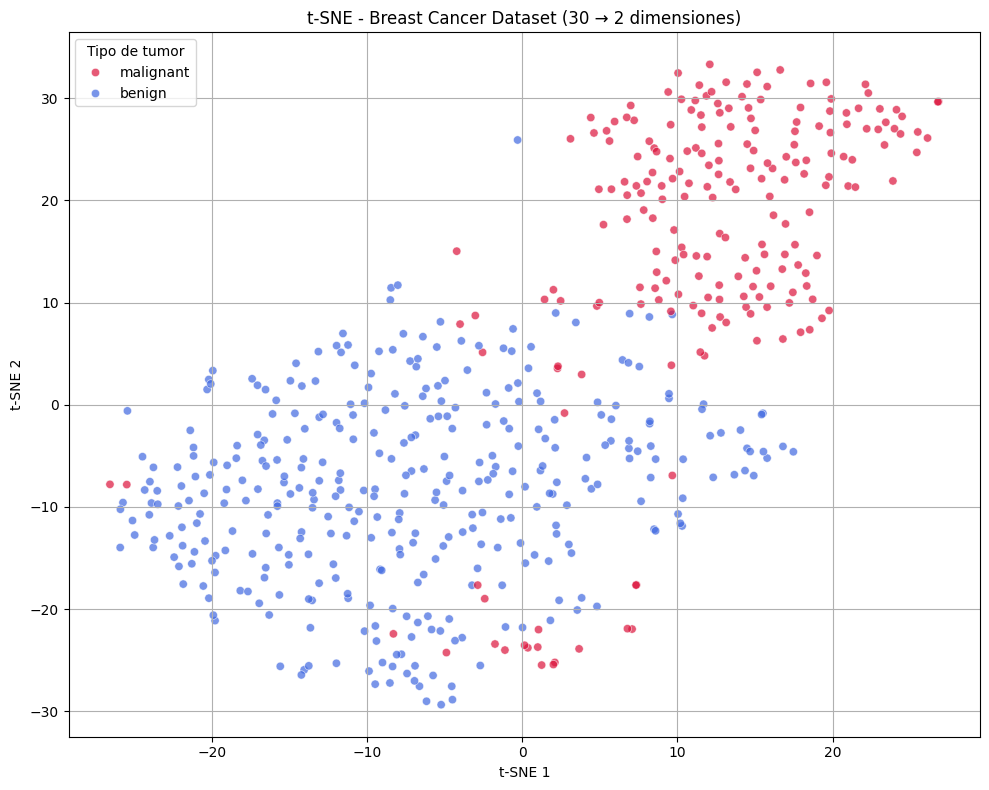

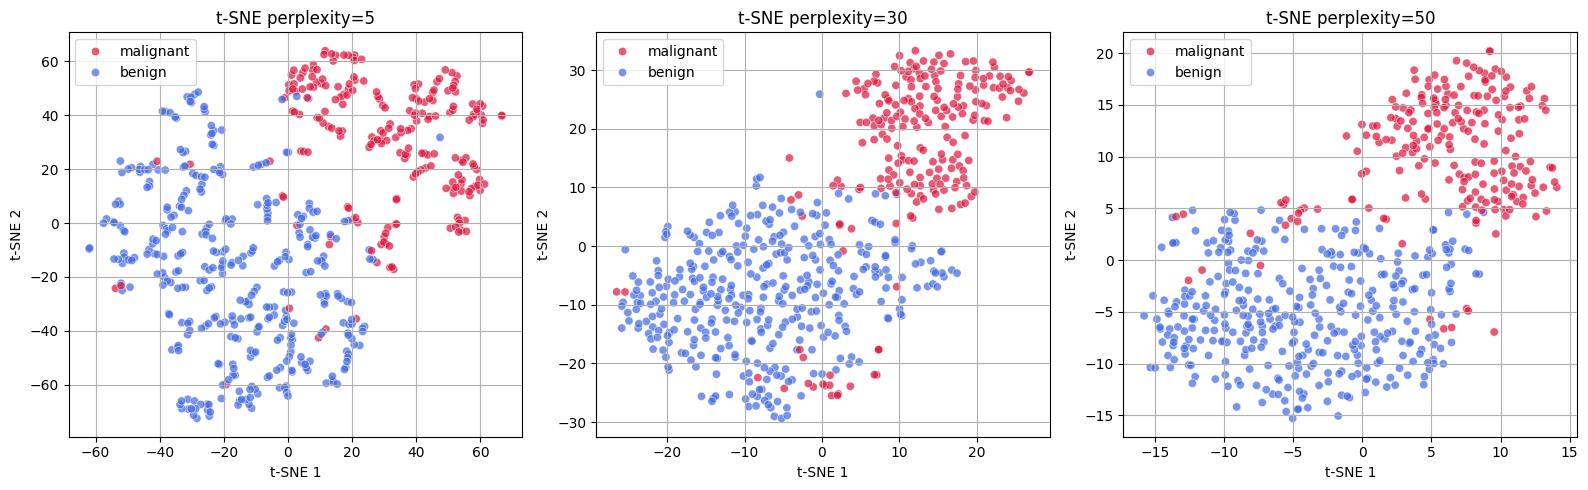

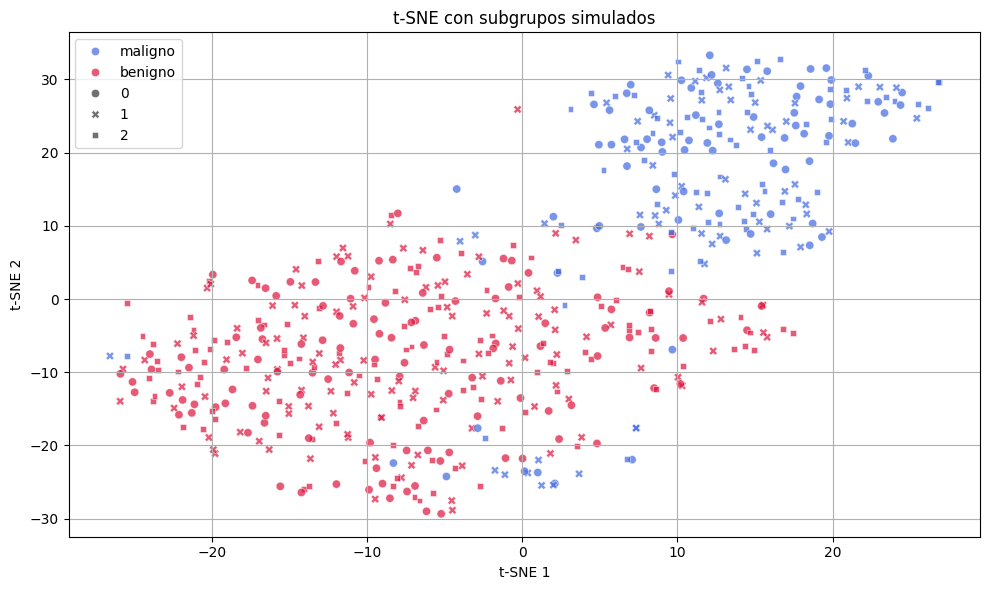

In [9]:
# t_Sne  g  p t
# ===========================================================
# t-SNE - Breast Cancer Dataset
# ===========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ===========================================================
# 1️ CARGA Y EXPLORACIÓN DEL DATASET
# ===========================================================
data = load_breast_cancer()

X = data.data          # matriz de características: 569 filas x 30 columnas
y = data.target        # etiquetas: 0 = maligno, 1 = benigno
feature_names = data.feature_names
target_names = data.target_names

print("Dimensiones X:", X.shape)
print("Target names:", target_names)

# Observación:
# X[0] ≈  [17.99, 10.38, 122.8, 1001, ...]  # valores originales
# y[0] = 0 → maligno

# ===========================================================
# 2️ ESCALAMIENTO DE VARIABLES
# ===========================================================
# Muy importante para t-SNE porque depende de distancias euclidianas.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ejemplo:
# X_scaled[0] ≈ [1.096, -0.336, 0.361, 0.208, ...] 
# Media=0, desviación estándar=1

# ===========================================================
# 3️ APLICACIÓN DE t-SNE
# ===========================================================
# Parametros típicos:
#   n_components=2 → queremos 2D para visualización
#   perplexity ≈ 30 → balance entre vecinos locales/globales
#   learning_rate ≈ 200 → velocidad de optimización
#   random_state=42 → reproducibilidad

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print("Forma de X_tsne:", X_tsne.shape)
# Output esperado: (569, 2)

# ===========================================================
# 4️ VISUALIZACIÓN DE t-SNE
# ===========================================================
plt.figure(figsize=(10,8))

# Scatter plot coloreado por tipo de tumor
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=[target_names[i] for i in y],
    palette=["crimson","royalblue"],
    alpha=0.7
)

plt.title("t-SNE - Breast Cancer Dataset (30 → 2 dimensiones)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Tipo de tumor")
plt.grid(True)
plt.tight_layout()
plt.show()

# Observación:
# t-SNE tiende a separar mejor los clusters maligno/benigno que solo mirar PCA
# Se pueden apreciar subgrupos internos en cada clase.

# ===========================================================
# 5️ COMPARACIÓN DE PARAMETROS (perplexity)
# ===========================================================
# Experimento para ver efecto de perplexity en la estructura de los clusters
perplexities = [5, 30, 50]

plt.figure(figsize=(16,5))

for i, p in enumerate(perplexities):

    tsne_p = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate=200,
        random_state=42
    )
    X_tsne_p = tsne_p.fit_transform(X_scaled)

    plt.subplot(1,3,i+1)
    sns.scatterplot(
        x=X_tsne_p[:,0],
        y=X_tsne_p[:,1],
        hue=[target_names[j] for j in y],
        palette=["crimson","royalblue"],
        alpha=0.7
    )
    plt.title(f"t-SNE perplexity={p}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True)

plt.tight_layout()
plt.show()

# Observación:
# Perplexity pequeño → t-SNE se enfoca en vecinos muy locales
# Perplexity grande → estructura global más suave, clusters pueden acercarse

# ===========================================================
# 6️ USO DE t-SNE PARA “EXPLORACIÓN DE SUBGRUPOS”
# ===========================================================
# Ejemplo: ver subgrupos de benignos
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=[f"benigno" if y[i]==1 else "maligno" for i in range(len(y))],
    style=[f"{i%3}" for i in range(len(y))],  # estilo para simular subgrupos
    palette=["royalblue","crimson"],
    alpha=0.7
)
plt.title("t-SNE con subgrupos simulados")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# Concepto:
# t-SNE permite explorar no solo separación de clases, sino
# patrones internos/subgrupos dentro de cada clase.

# ===========================================================
# 7️ EJERCICIO DE PRÁCTICA
# ===========================================================
# Parte conceptual que el profe podría preguntar:
# - ¿Qué efecto tiene escalar los datos antes de t-SNE? (distancias)
# - ¿Qué significa perplexity? (vecinos “efectivos” considerados)
# - ¿Se puede usar t-SNE para clasificación directa? (no, solo exploración)
# - ¿Qué diferencias clave hay con PCA? (t-SNE preserva distancias locales,
#   PCA maximiza varianza global)

In [10]:
# ===========================================================
# t-SNE - Breast Cancer Dataset (desde CSV)
# ===========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ===========================================================
# 1️ CARGA Y EXPLORACIÓN DEL CSV
# ===========================================================
# Supongamos que BreastCancer.csv tiene 30 columnas de features + 'target'

df = pd.read_csv("BreastCancer.csv")

# Revisar las primeras filas
print(df.head())

# Separar X e y
target_col = 'target'  # columna objetivo
X = df.drop(columns=[target_col])
y = df[target_col]

print("\nDimensiones X:", X.shape)
print("Target único:", np.unique(y))
# Ejemplo de salida:
# Dimensiones X: (569, 30)
# Target único: [0 1]

# ===========================================================
# 2️ ESCALAMIENTO DE VARIABLES
# ===========================================================
# Muy importante para t-SNE porque depende de distancias
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ejemplo:
# X_scaled[0] ≈ [-0.34, 0.98, 0.12, ...]

# ===========================================================
# 3️ APLICACIÓN DE t-SNE
# ===========================================================
# n_components=2 → para visualización
# perplexity=30 → vecinos “efectivos”
# learning_rate=200 → velocidad de optimización
# random_state=42 → reproducibilidad

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print("\nForma de X_tsne:", X_tsne.shape)
# Output esperado: (569, 2)

# ===========================================================
# 4️ SCATTER PLOT t-SNE
# ===========================================================
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=[ 'Maligno' if i==0 else 'Benigno' for i in y],
    palette=["crimson","royalblue"],
    alpha=0.7
)

plt.title("t-SNE - Breast Cancer Dataset (CSV)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Tipo de tumor")
plt.grid(True)
plt.tight_layout()
plt.show()

# Observación:
# t-SNE separa claramente maligno vs benigno y puede mostrar subgrupos internos

# ===========================================================
# 5️ EXPERIMENTO CON DIFERENTES PERPLEXITIES
# ===========================================================
perplexities = [5, 30, 50]

plt.figure(figsize=(16,5))

for i, p in enumerate(perplexities):
    tsne_p = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate=200,
        random_state=42
    )
    X_tsne_p = tsne_p.fit_transform(X_scaled)

    plt.subplot(1,3,i+1)
    sns.scatterplot(
        x=X_tsne_p[:,0],
        y=X_tsne_p[:,1],
        hue=[ 'Maligno' if j==0 else 'Benigno' for j in y],
        palette=["crimson","royalblue"],
        alpha=0.7
    )
    plt.title(f"t-SNE perplexity={p}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True)

plt.tight_layout()
plt.show()

# Observación:
# - Perplexity bajo → clusters más locales, detalles internos
# - Perplexity alto → estructura global más suave, clusters más juntos

# ===========================================================
# 6️ EJERCICIO DE PRÁCTICA (conceptual)
# ===========================================================
# - ¿Por qué es importante escalar los datos antes de t-SNE?
# - ¿Qué significa perplexity y cómo afecta la visualización?
# - ¿Se puede usar t-SNE directamente para clasificación? (no, solo exploración)
# - Comparar resultados con PCA (t-SNE preserva distancias locales, PCA maximiza varianza global)

FileNotFoundError: [Errno 2] No such file or directory: 'BreastCancer.csv'

       P01_amabilidad  P02_espera  P03_resolucion  P04_atencion  P05_calidad  \
count          300.00      300.00          300.00        300.00       300.00   
mean             2.50        2.52            2.48          2.47         2.49   
std              0.84        0.88            0.86          0.82         0.85   
min              1.00        1.00            1.00          1.00         1.00   
25%              2.00        2.00            2.00          2.00         2.00   
50%              3.00        3.00            2.00          3.00         2.00   
75%              3.00        3.00            3.00          3.00         3.00   
max              5.00        5.00            5.00          5.00         5.00   

       P06_variedad  P07_precio  P08_presentacion  P09_ambiente  P10_limpieza  \
count        300.00      300.00            300.00        300.00        300.00   
mean           2.51        2.51              2.50          2.62          2.57   
std            0.87        0.92     

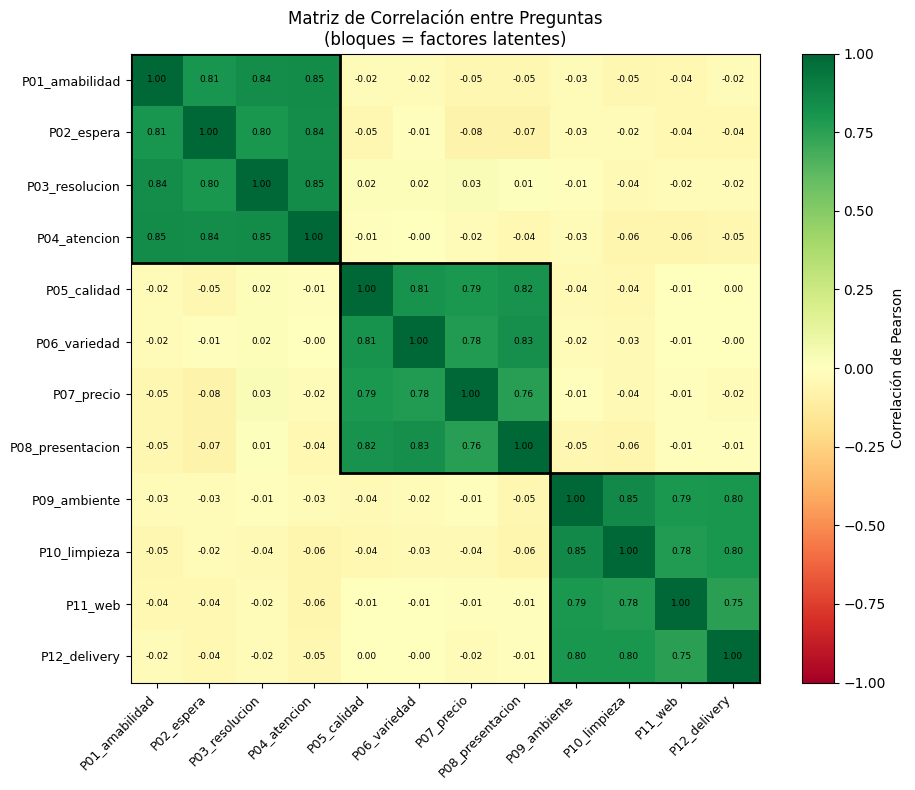

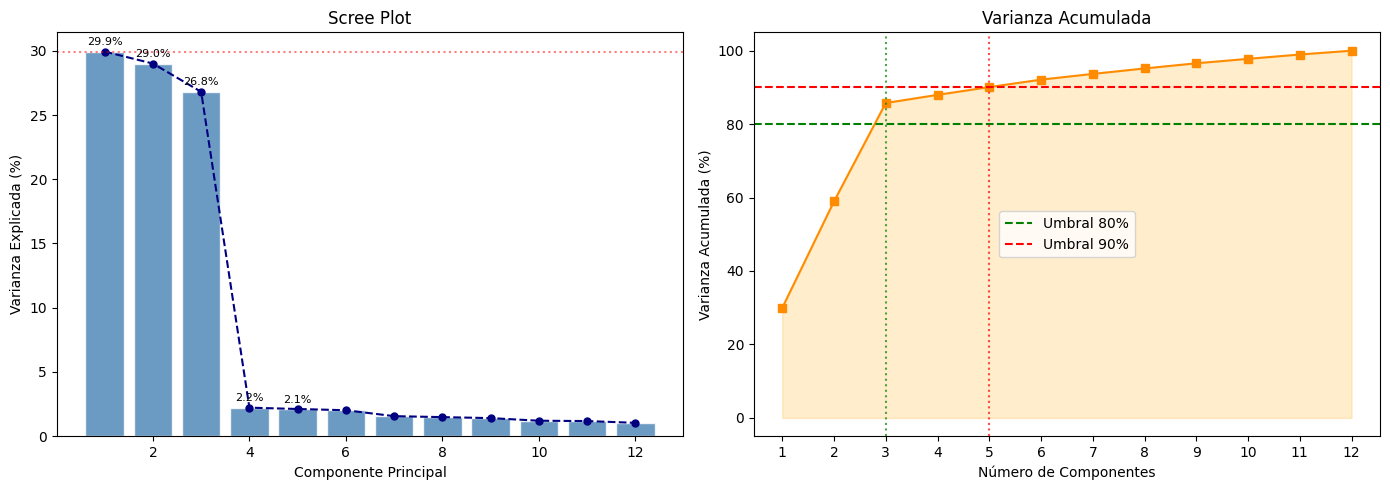

Componentes para 80% varianza: 3
Componentes para 90% varianza: 5

Varianza explicada por componente:
  PC1: 29.94%  (acumulado: 29.94%)
  PC2: 29.00%  (acumulado: 58.94%)
  PC3: 26.81%  (acumulado: 85.75%)
  PC4: 2.22%  (acumulado: 87.97%)
  PC5: 2.12%  (acumulado: 90.09%)
  PC6: 2.02%  (acumulado: 92.11%)


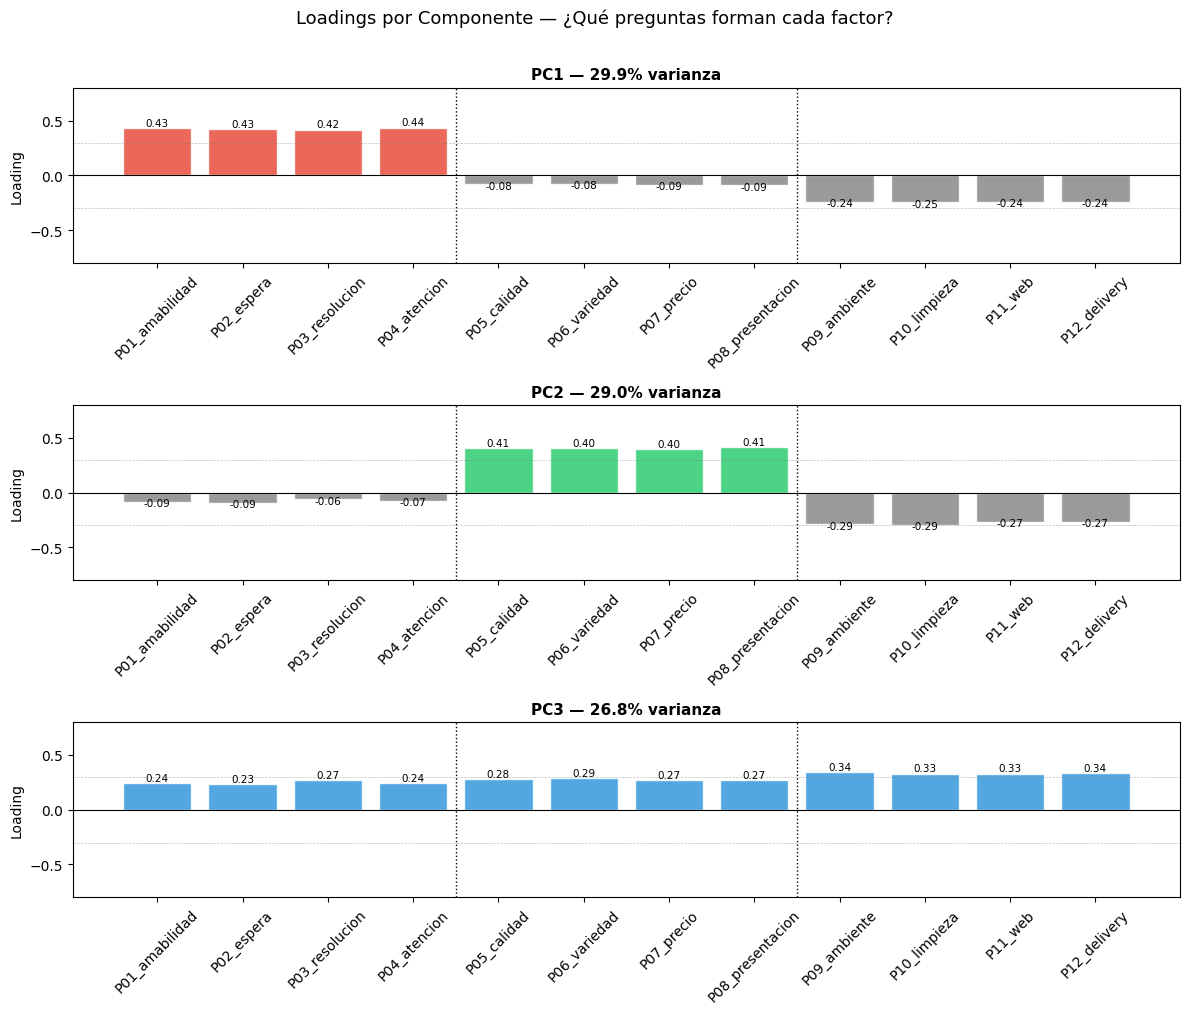

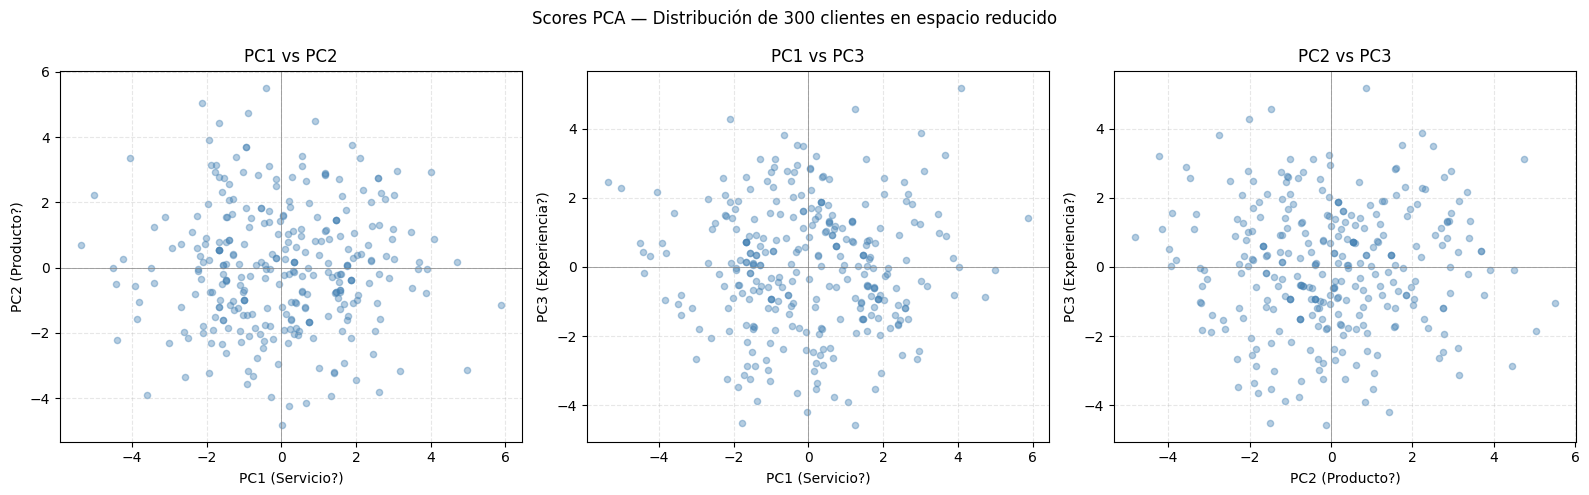

Error de reconstrucción (MSE) con 3 componentes: 0.1425
Varianza retenida: 85.7%
Varianza perdida:  14.3%


In [11]:
# pc2  c  l   u e  de
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. GENERAR ENCUESTA SIMULADA
#    300 clientes, 12 preguntas, 3 factores latentes ocultos
# ============================================================
np.random.seed(42)
n = 300

# Factor latente de cada cliente (no observable)
satisfaccion_servicio   = np.random.randn(n)
satisfaccion_producto   = np.random.randn(n)
satisfaccion_experiencia = np.random.randn(n)

def likert(x):
    """Convierte score continuo a escala Likert 1-5"""
    return np.clip(np.round(2.5 + x * 0.8), 1, 5).astype(int)

# Preguntas generadas desde cada factor + ruido
data = {
    'P01_amabilidad':    likert(satisfaccion_servicio + np.random.randn(n)*0.3),
    'P02_espera':        likert(satisfaccion_servicio + np.random.randn(n)*0.4),
    'P03_resolucion':    likert(satisfaccion_servicio + np.random.randn(n)*0.3),
    'P04_atencion':      likert(satisfaccion_servicio + np.random.randn(n)*0.2),
    'P05_calidad':       likert(satisfaccion_producto + np.random.randn(n)*0.3),
    'P06_variedad':      likert(satisfaccion_producto + np.random.randn(n)*0.4),
    'P07_precio':        likert(satisfaccion_producto + np.random.randn(n)*0.5),
    'P08_presentacion':  likert(satisfaccion_producto + np.random.randn(n)*0.3),
    'P09_ambiente':      likert(satisfaccion_experiencia + np.random.randn(n)*0.3),
    'P10_limpieza':      likert(satisfaccion_experiencia + np.random.randn(n)*0.2),
    'P11_web':           likert(satisfaccion_experiencia + np.random.randn(n)*0.5),
    'P12_delivery':      likert(satisfaccion_experiencia + np.random.randn(n)*0.4),
}
df = pd.DataFrame(data)
print(df.describe().round(2))

# ============================================================
# 2. PREPROCESAMIENTO
# ============================================================
# TODO ── Pregunta conceptual:
#   ¿Por qué usar StandardScaler (z-score) y no MinMaxScaler
#   antes de PCA en datos de encuesta Likert?
#   Escribe tu respuesta aquí:
#   R: ___________________________________________________

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ============================================================
# 3. MATRIZ DE CORRELACIÓN — Exploración previa
#    Antes de PCA, siempre visualiza correlaciones.
#    Si las variables no están correlacionadas, PCA no sirve.
# ============================================================
corr = df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='Correlación de Pearson')
plt.xticks(range(12), df.columns, rotation=45, ha='right', fontsize=9)
plt.yticks(range(12), df.columns, fontsize=9)
plt.title('Matriz de Correlación entre Preguntas\n(bloques = factores latentes)', fontsize=12)
for i in range(12):
    for j in range(12):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6.5)
# Dibujar cajas para los 3 bloques
for start, end in [(0,4), (4,8), (8,12)]:
    rect = plt.Rectangle((start-0.5, start-0.5), end-start, end-start,
                          fill=False, edgecolor='black', linewidth=2)
    plt.gca().add_patch(rect)
plt.tight_layout()
plt.show()

# TODO ── Observa la matriz de correlación y responde:
#   ¿Las preguntas P01-P04 están más correlacionadas entre sí
#   o con P05-P08? ¿Qué indica esto sobre los factores latentes?
#   R: ___________________________________________________
# ============================================================
# 4. SCREE PLOT — ¿Cuántos componentes conservar?
# ============================================================
pca_full = PCA()
pca_full.fit(X_scaled)

var_ratio = pca_full.explained_variance_ratio_
var_acum  = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: varianza por componente
axes[0].bar(range(1, 13), var_ratio * 100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, 13), var_ratio * 100, 'o--', color='navy', markersize=5)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot')
axes[0].axhline(y=var_ratio[0]*100, color='red', linestyle=':', alpha=0.5)
for i, v in enumerate(var_ratio[:5]):
    axes[0].text(i+1, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=8)

# Panel derecho: varianza acumulada
axes[1].plot(range(1, 13), var_acum * 100, 's-', color='darkorange', markersize=6)
axes[1].fill_between(range(1, 13), var_acum * 100, alpha=0.2, color='orange')
axes[1].axhline(y=80, color='green',  linestyle='--', label='Umbral 80%')
axes[1].axhline(y=90, color='red',    linestyle='--', label='Umbral 90%')
n_80 = np.argmax(var_acum >= 0.80) + 1
n_90 = np.argmax(var_acum >= 0.90) + 1
axes[1].axvline(x=n_80, color='green', linestyle=':', alpha=0.7)
axes[1].axvline(x=n_90, color='red',   linestyle=':', alpha=0.7)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada')
axes[1].legend()
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

print(f"Componentes para 80% varianza: {n_80}")
print(f"Componentes para 90% varianza: {n_90}")
print(f"\nVarianza explicada por componente:")
for i, v in enumerate(var_ratio[:6]):
    print(f"  PC{i+1}: {v*100:.2f}%  (acumulado: {var_acum[i]*100:.2f}%)")

# TODO ── Completa las respuestas:
# a) ¿Cuántos componentes tienen varianza > que el promedio (1/12 = 8.33%)?
#    R: ___________________________________________________
# b) Según el Scree Plot, ¿dónde está el "codo"?
#    R: ___________________________________________________
# c) ¿Coincide el número de componentes óptimos con los
#    3 factores latentes que fueron inyectados en los datos?
#    R: ___________________________________________________
# ============================================================
# 5. LOADINGS — ¿Qué preguntas forman cada componente?
#    Esto es el corazón del análisis factorial con PCA.
# ============================================================
pca_3 = PCA(n_components=3)
pca_3.fit(X_scaled)

loadings = pca_3.components_   # shape: (3, 12)
preguntas = df.columns.tolist()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
colores_barra = ['#e74c3c', '#2ecc71', '#3498db']
nombres_pc = ['PC1', 'PC2', 'PC3']

for idx, ax in enumerate(axes):
    vals = loadings[idx]
    bar_colors = [colores_barra[idx] if v > 0 else '#888888' for v in vals]
    bars = ax.bar(preguntas, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline( 0.3, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axhline(-0.3, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_title(f'{nombres_pc[idx]} — {pca_3.explained_variance_ratio_[idx]*100:.1f}% varianza',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Loading')
    ax.set_ylim(-0.8, 0.8)
    ax.tick_params(axis='x', rotation=45)
    # Anotar valores
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + (0.02 if v >= 0 else -0.04),
                f'{v:.2f}', ha='center', fontsize=7.5)
    # Líneas divisorias de grupos
    for x in [3.5, 7.5]:
        ax.axvline(x=x, color='black', linewidth=1, linestyle=':')

plt.suptitle('Loadings por Componente — ¿Qué preguntas forman cada factor?',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# TODO ── Interpreta cada componente:
# PC1 tiene loadings altos en P____ a P____ → representa el factor: ___________
# PC2 tiene loadings altos en P____ a P____ → representa el factor: ___________
# PC3 tiene loadings altos en P____ a P____ → representa el factor: ___________
#
# ¿PCA "descubrió" los 3 factores latentes que fueron inyectados?
# R: ___________________________________________________
# ============================================================
# 6. SCORES — Posición de cada cliente en el nuevo espacio
#    Esto permite SEGMENTAR clientes por tipo de satisfacción
# ============================================================
X_pca = pca_3.transform(X_scaled)   # shape: (300, 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pares = [(0,1), (0,2), (1,2)]
etiquetas = ['PC1 (Servicio?)', 'PC2 (Producto?)', 'PC3 (Experiencia?)']

for ax, (i, j) in zip(axes, pares):
    ax.scatter(X_pca[:, i], X_pca[:, j], alpha=0.4, s=20, color='steelblue')
    ax.set_xlabel(etiquetas[i], fontsize=10)
    ax.set_ylabel(etiquetas[j], fontsize=10)
    ax.set_title(f'{etiquetas[i].split()[0]} vs {etiquetas[j].split()[0]}')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Scores PCA — Distribución de 300 clientes en espacio reducido', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# 7. RECONSTRUCCIÓN — Coste de la reducción
# ============================================================
X_reconstruido = pca_3.inverse_transform(X_pca)

error_total = np.mean((X_scaled - X_reconstruido) ** 2)
print(f"Error de reconstrucción (MSE) con 3 componentes: {error_total:.4f}")
print(f"Varianza retenida: {pca_3.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Varianza perdida:  {(1 - pca_3.explained_variance_ratio_.sum())*100:.1f}%")

# TODO ── Pregunta:
#   Si el error de reconstrucción fuera 0.0000, ¿qué significaría?
#   ¿En qué situación ocurriría eso?
#   R: ___________________________________________________

Shape X_scaled: (500, 8)
Columnas df: ['frec_compra', 'ticket_promedio', 'dias_ultima_compra', 'n_categorias', 'tasa_devolucion', 'uso_app', 'uso_cupon', 'nps_score', 'segmento_real']

Primeras filas:
   frec_compra  ticket_promedio  dias_ultima_compra  n_categorias  \
0     8.745071       341.704142           11.476885      4.523030   
1     7.295788       382.553603            0.365823      2.534270   
2     6.480753       368.854840            0.000000      1.587696   

   tasa_devolucion   uso_app  uso_cupon  nps_score segmento_real  
0         0.042975  5.648795   2.263370   9.920922      VIP Fiel  
1         0.057259  3.130080   0.000000   8.325255      VIP Fiel  
2         0.093969  5.661336   1.054023   7.290302      VIP Fiel  


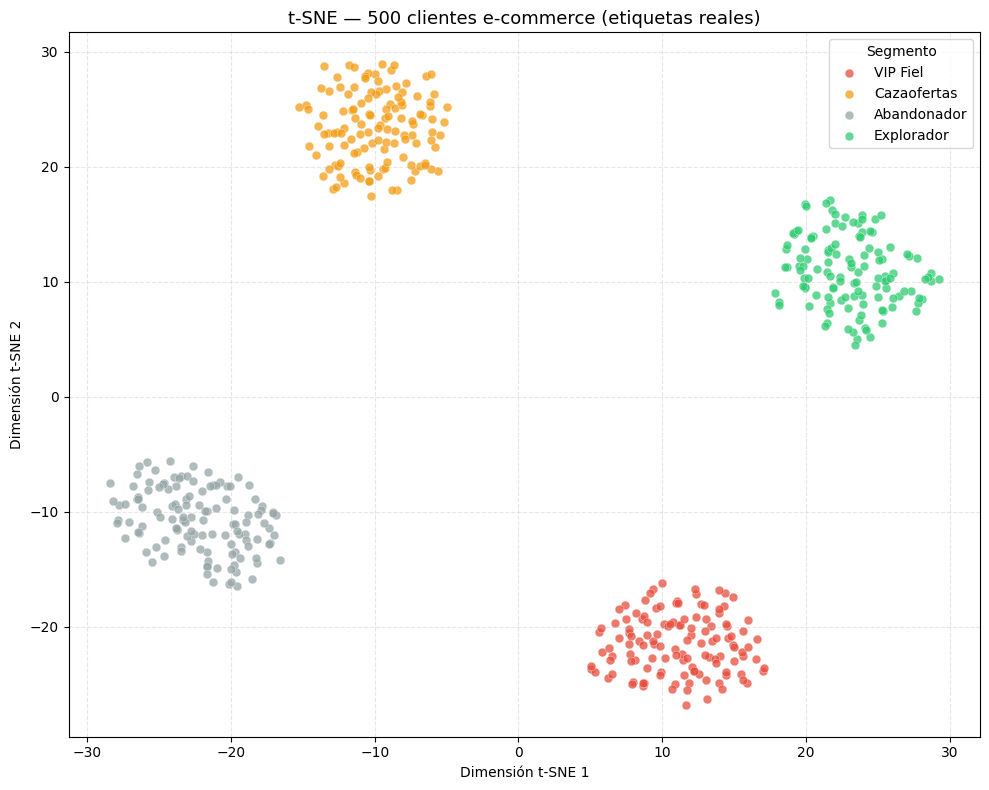

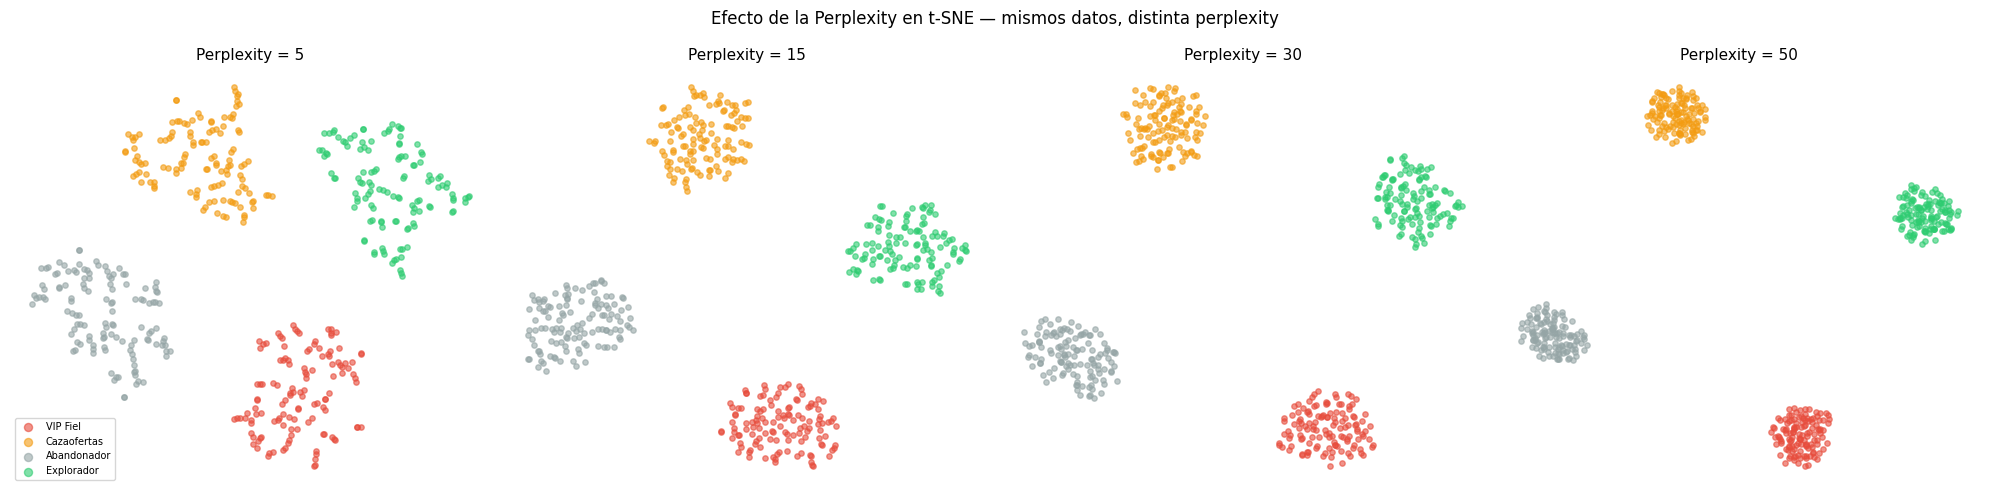

C:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


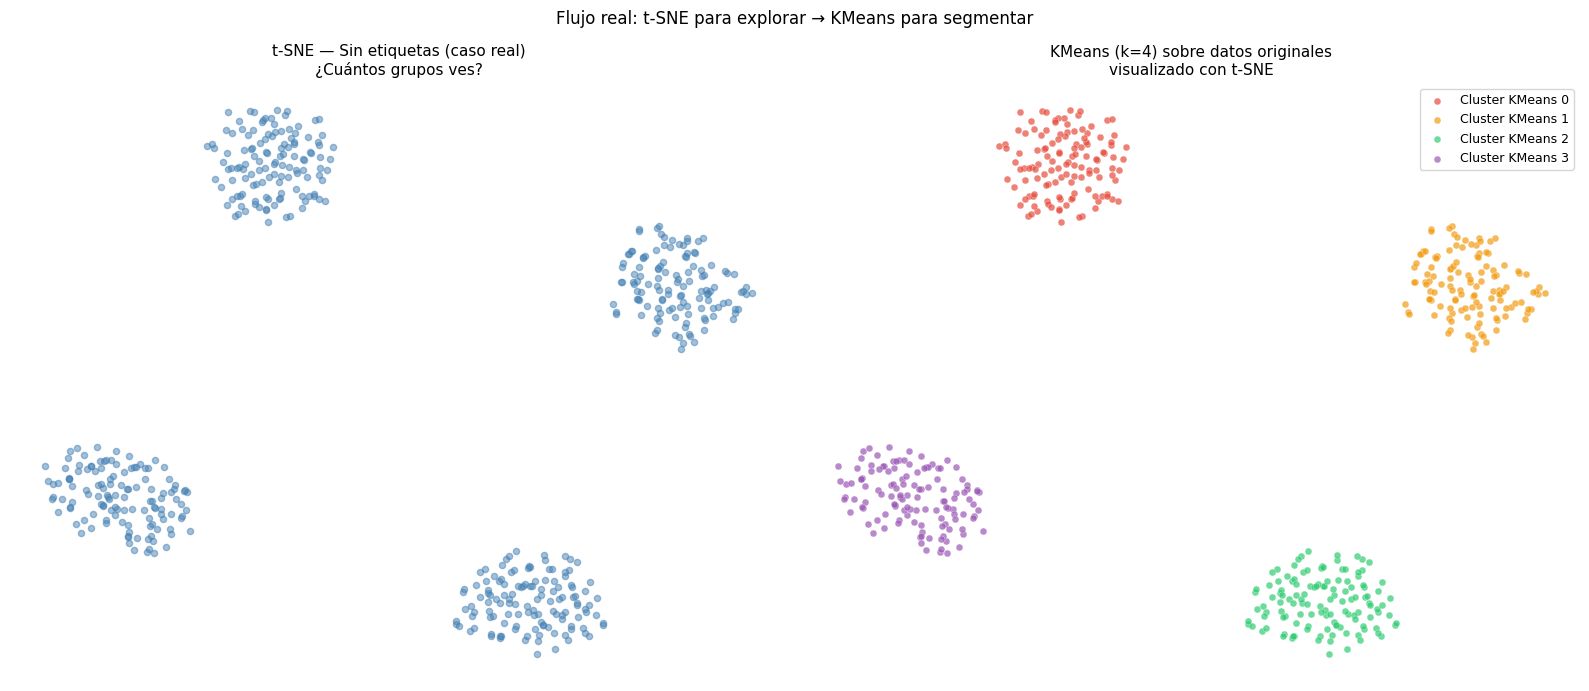

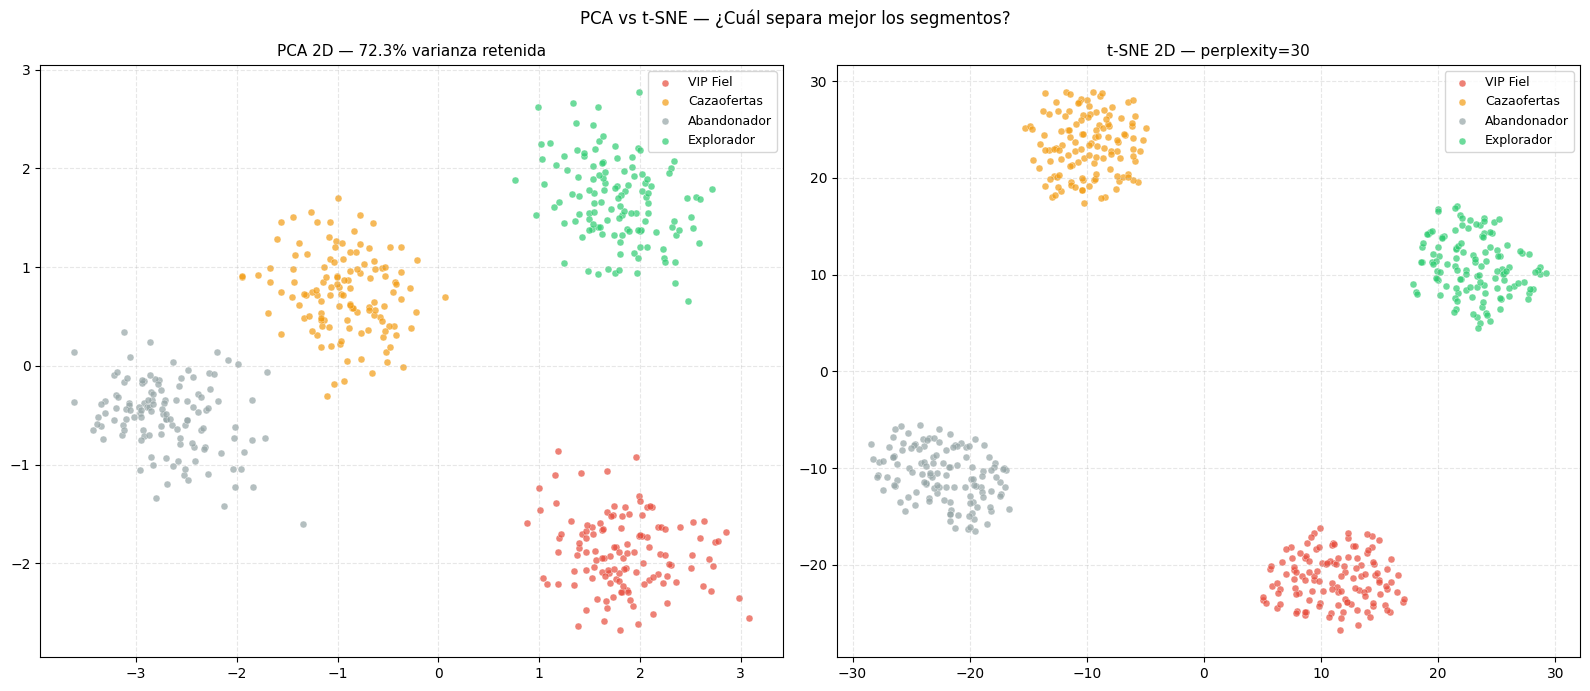

Varianza explicada PCA:
  PC1: 47.9%
  PC2: 24.4%
  Total: 72.3%


In [16]:
#TSNE -- cl  qa u d e
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ============================================================
# 1. GENERAR DATOS
# ============================================================
np.random.seed(42)
n_por_segmento = 125

perfiles = {
    'VIP Fiel':    [  8,  350,   5,  3, 0.05,  6,  1,  9],
    'Cazaofertas': [  2,   80,  20,  2, 0.10,  2,  5,  6],
    'Abandonador': [  1,  120,  90,  1, 0.08,  1,  0,  3],
    'Explorador':  [  4,  200,  15,  7, 0.25,  8,  2,  7],
}
std = [1.5, 60, 10, 1, 0.03, 1.5, 0.8, 1.2]
cols = ['frec_compra','ticket_promedio','dias_ultima_compra',
        'n_categorias','tasa_devolucion','uso_app','uso_cupon','nps_score']

bloques, segmentos_reales = [], []
for nombre, centro in perfiles.items():
    bloque = np.random.randn(n_por_segmento, 8) * std + centro
    bloques.append(bloque)
    segmentos_reales.extend([nombre] * n_por_segmento)

X_raw = np.vstack(bloques)
X_raw = np.clip(X_raw, 0, None)

df = pd.DataFrame(X_raw, columns=cols)
df['segmento_real'] = segmentos_reales  # ← columna que faltaba

# ============================================================
# 2. ESCALAR  (solo las 8 variables numéricas, NO segmento_real)
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols])  # ← explícito: solo cols numéricas

print("Shape X_scaled:", X_scaled.shape)
print("Columnas df:", df.columns.tolist())
print("\nPrimeras filas:")
print(df.head(3))

# ============================================================
# 3. t-SNE
# ============================================================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    max_iter=1000,       # sklearn >= 1.5
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)

colores_seg = {
    'VIP Fiel':    '#e74c3c',
    'Cazaofertas': '#f39c12',
    'Abandonador': '#95a5a6',
    'Explorador':  '#2ecc71'
}

plt.figure(figsize=(10, 8))
for seg, color in colores_seg.items():
    mask = df['segmento_real'] == seg
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=seg, alpha=0.75, s=40,
                edgecolors='white', linewidths=0.3)

plt.title('t-SNE — 500 clientes e-commerce (etiquetas reales)', fontsize=13)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Segmento', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
# TODO — Observa el gráfico y responde:
#   ¿Los 4 segmentos aparecen separados visualmente?
#   ¿Qué pares de segmentos quedan más cerca entre sí y por qué?
#   (Pista: revisa sus perfiles en el paso 1)
#   R: ___________________________________________________
# ============================================================
# 4. IMPACTO DE PERPLEXITY — Hiperparámetro crítico
# ============================================================
perplexidades = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, perp in zip(axes, perplexidades):
    tsne_p = TSNE(n_components=2, perplexity=perp,
                  max_iter=800, random_state=42)
    Xp = tsne_p.fit_transform(X_scaled)
    for seg, color in colores_seg.items():
        mask = df['segmento_real'] == seg
        ax.scatter(Xp[mask, 0], Xp[mask, 1],
                   c=color, alpha=0.6, s=15, label=seg)
    ax.set_title(f'Perplexity = {perp}', fontsize=11)
    ax.axis('off')

axes[0].legend(fontsize=7, markerscale=1.5, loc='lower left')
plt.suptitle('Efecto de la Perplexity en t-SNE — mismos datos, distinta perplexity',
             fontsize=12)
plt.tight_layout()
plt.show()

# TODO — Responde:
# a) Con perplexity=5 los clusters se ven fragmentados. ¿Por qué?
#    (Pista: σᵢ pequeño → solo considera vecinos muy inmediatos)
#    R: ___________________________________________________
#
# b) Con perplexity=50 los clusters se comprimen. ¿Qué estructura
#    se pierde cuando la perplexity es muy alta?
#    R: ___________________________________________________
#
# c) ¿Cuál perplexity te parece óptima para estos datos? ¿Por qué?
#    R: ___________________________________________________
# ============================================================
# 5. t-SNE SIN ETIQUETAS — Simulando el caso real
#    En producción NO conoces los segmentos. Usas t-SNE para
#    descubrirlos visualmente, luego validas con KMeans.
# ============================================================
# Usar la mejor perplexity del paso anterior
tsne_best = TSNE(n_components=2, perplexity=30,
                 max_iter=1000, random_state=42)
X_tsne_best = tsne_best.fit_transform(X_scaled)

# KMeans sobre el espacio original (NO sobre t-SNE)
# t-SNE distorsiona distancias globales → no usar para clustering
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=42)
kmeans.fit(X_scaled)
labels_kmeans = kmeans.labels_

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: sin etiquetas (lo que ves en producción)
axes[0].scatter(X_tsne_best[:, 0], X_tsne_best[:, 1],
                alpha=0.5, s=20, color='steelblue')
axes[0].set_title('t-SNE — Sin etiquetas (caso real)\n¿Cuántos grupos ves?',
                  fontsize=11)
axes[0].axis('off')

# Panel derecho: KMeans sobre espacio original, visualizado en t-SNE
cmap_k = ['#e74c3c', '#f39c12', '#2ecc71', '#9b59b6']
for k in range(4):
    mask = labels_kmeans == k
    axes[1].scatter(X_tsne_best[mask, 0], X_tsne_best[mask, 1],
                    c=cmap_k[k], label=f'Cluster KMeans {k}',
                    alpha=0.7, s=25, edgecolors='white', linewidths=0.3)
axes[1].set_title('KMeans (k=4) sobre datos originales\nvisualizado con t-SNE',
                  fontsize=11)
axes[1].legend(fontsize=9)
axes[1].axis('off')

plt.suptitle('Flujo real: t-SNE para explorar → KMeans para segmentar',
             fontsize=12)
plt.tight_layout()
plt.show()

# TODO — Pregunta crítica:
#   ¿Por qué aplicamos KMeans sobre X_scaled (8 dimensiones originales)
#   y NO sobre X_tsne (2 dimensiones t-SNE)?
#   ¿Qué propiedad de t-SNE hace que sea peligroso clusterizar
#   directamente sobre sus coordenadas 2D?
#   R: ___________________________________________________
# ============================================================
# 6. COMPARACIÓN: t-SNE vs PCA en este mismo dataset
# ============================================================
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
var = pca_2d.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
titulos = [
    f'PCA 2D — {var.sum()*100:.1f}% varianza retenida',
    't-SNE 2D — perplexity=30'
]
projs = [X_pca, X_tsne_best]

for ax, proj, titulo in zip(axes, projs, titulos):
    for seg, color in colores_seg.items():
        mask = df['segmento_real'] == seg
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=color, label=seg, alpha=0.7, s=25,
                   edgecolors='white', linewidths=0.3)
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('PCA vs t-SNE — ¿Cuál separa mejor los segmentos?', fontsize=12)
plt.tight_layout()
plt.show()

print("Varianza explicada PCA:")
for i, v in enumerate(var):
    print(f"  PC{i+1}: {v*100:.1f}%")
print(f"  Total: {var.sum()*100:.1f}%")

# TODO — Responde:
#   Si PCA separa bien los segmentos con solo 2 componentes,
#   ¿tiene sentido usar t-SNE en este caso?
#   ¿En qué tipo de datos t-SNE aportaría MUCHO más que PCA?
#   R: ___________________________________________________